# 04 — Price Modelling

**Task 1:** Price regression (predict sale price per m²)  
**Task 2:** Price-band classification (low / medium / high)

---

## Overview

This notebook trains and evaluates several machine learning models to predict real estate prices
from the cleaned Tehran dataset.

### Models Evaluated

| Model | Task |
|---|---|
| Linear Regression | Price regression baseline |
| K-Nearest Neighbours (KNN) | Price regression |
| Decision Tree Regressor | Price regression |
| MLP (Neural Network) | Price regression |
| Logistic Regression | Price-band classification |
| Decision Tree Classifier | Price-band classification |

### Feature Engineering
- Log-transformation of skewed price and area columns.
- One-hot encoding of categorical columns (`cat2_slug`, `cat3_slug`, `neighborhood_slug`, …).
- StandardScaler applied before KNN and MLP.

### Key Results
- Best regression model: **MLP** (lowest RMSE on test set).
- Best classification model: **Decision Tree** (highest weighted F1 for price-band prediction).

### Input
`../data/divar_tehran_nonnum_filled_final.pkl`

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_pickle(r"C:\Users\kourosh\Desktop\daqiqe Project\modelsazi khodam\divar_tehran_nonnum_filled_final.pkl")

In [4]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius
0,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,agency,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,fixed,30000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.773281,51.442539,500.0
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,personal,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,fixed,26000000.0,...,False,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.703865,51.373459,NaN
2,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,agency,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,fixed,95000000.0,...,False,water_heater,heater,water_cooler,squat,north,ceramic,35.791080,51.426540,NaN
3,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,agency,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,fixed,12000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.729832,51.505466,500.0
4,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,agency,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر ب...,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ار...,free,27000000.0,...,True,package,shoofaj,water_cooler,squat_seat,south,ceramic,35.733952,51.380608,500.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190904 entries, 0 to 190903
Data columns (total 40 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                190904 non-null  object 
 1   cat3_slug                190904 non-null  object 
 2   city_slug                190904 non-null  object 
 3   neighborhood_slug        190904 non-null  object 
 4   created_at_month         190904 non-null  object 
 5   user_type                190904 non-null  object 
 6   description              190904 non-null  object 
 7   title                    190898 non-null  object 
 8   rent_mode                190904 non-null  object 
 9   rent_value               190904 non-null  float64
 10  rent_type                190904 non-null  object 
 11  price_mode               100879 non-null  object 
 12  price_value              100681 non-null  float64
 13  credit_mode              86058 non-null   object 
 14  cred

###### ستون های حذفی برای تحلیل خرید:
6   description              190904 non-null  object 
-----
 7   title                    190898 non-null  object 
----
 8   rent_mode                190904 non-null  object 
----
 9   rent_value               190904 non-null  float64
----
 10  rent_type                190904 non-null  object 
----
  4   created_at_month         190904 non-null  object 
----
   15  rent_credit_transform    86056 non-null   object 
----
 16  transformable_price      190904 non-null  bool   
----
 39  location_radius          85724 non-null   float64
----


In [6]:
df["price_mode"].dropna().unique()

array(['fixed', 'negotiable', 'free'], dtype=object)

In [7]:
df["credit_mode"].dropna().unique()

array(['fixed', 'free', 'negotiable'], dtype=object)

In [8]:
df["credit_value"].dropna().unique()

array([6.25000000e+08, 7.50000000e+08, 9.50000000e+08, 5.00000000e+08,
       1.20000000e+09, 7.00000000e+08, 1.00000000e+09, 1.10000000e+08,
       1.50000000e+08, 1.50000000e+09, 2.50000000e+08, 3.00000000e+08,
       8.00000000e+08, 4.00000000e+08, 6.00000000e+08, 4.50000000e+08,
       3.50000000e+08, 6.50000000e+08, 3.65000000e+08, 1.00000000e+08,
       2.00000000e+09, 3.85000000e+08, 2.80000000e+08, 1.11111110e+07,
       2.00000000e+08, 9.00000000e+08, 1.30000000e+08, 5.30000000e+08,
       6.75000000e+08, 8.00000000e+07, 3.30000000e+08, 9.75000000e+08,
       4.25000000e+08, 6.45000000e+08, 1.55000000e+08, 3.70000000e+08,
       3.47500000e+08, 1.80000000e+09, 1.85000000e+09, 2.00000000e+07,
       3.05000000e+08, 6.20000000e+08, 2.00000000e+06, 4.20000000e+08,
       1.15000000e+09, 5.60000000e+08, 3.02500000e+08, 3.47000000e+08,
       1.50000000e+07, 4.35000000e+08, 3.60000000e+08, 5.20000000e+08,
       1.11111100e+06, 1.11111111e+08, 1.90000000e+09, 5.00000000e+06,
      

In [9]:
df["building_direction"].dropna().unique()

array(['south', 'north', 'west', 'east'], dtype=object)

In [10]:
df["deed_type"].dropna().unique()

array(['single_page', 'other', 'written_agreement', 'multi_page'],
      dtype=object)

In [11]:
df["cat2_slug"].dropna().unique()

array(['residential-sell', 'residential-rent', 'commercial-rent',
       'commercial-sell', 'real-estate-services', 'temporary-rent'],
      dtype=object)

In [12]:
df["cat3_slug"].dropna().unique()

array(['apartment-sell', 'apartment-rent', 'office-rent', 'plot-old',
       'house-villa-rent', 'shop-rent', 'shop-sell',
       'industry-agriculture-business-rent', 'office-sell', 'presell',
       'house-villa-sell', 'suite-apartment', 'villa',
       'industry-agriculture-business-sell', 'partnership', 'workspace'],
      dtype=object)

<div dir="rtl">

### نکات تحلیلی درباره ستون‌های موثر و اولویت‌بندی برای ارزیابی ملک

- **ابعاد بنا (building_size) و زمین (land_size):** از مهم‌ترین معیارهای قیمت و ارزش ملک هستند. متراژ بیشتر معمولاً قیمت کل را افزایش می‌دهد، اما قیمت هر متر مربع ممکن است در خانه‌ها و زمین‌های کوچک‌تر بالاتر باشد.
- **تعداد اتاق (rooms_count):** هرچه تعداد اتاق بیشتر، ارزش ملک بالاتر؛ مخصوصاً برای خانواده‌های بزرگ.
- **طبقه (floor):** طبقات بالاتر اغلب نور، ویو و آرامش بیشتری دارند. اگر آسانسور وجود داشته باشد، واحدهای طبقه بالا نه ‌تنها راحتی دارند بلکه ممکن است قیمت بیشتری هم پیدا کنند. بدون آسانسور، واحدهای طبقات پایین در اولویت قرار می‌گیرند.
- **آسانسور (has_elevator):** وجود آسانسور یکی از مهم‌ترین امتیازات ساختمانی است؛ به ویژه در ساختمان‌های چند طبقه.
- **پارکینگ (has_parking):** داشتن پارکینگ به خصوص در شهرهای بزرگ یک مزیت کلیدی است و تاثیر قابل توجهی بر قیمت دارد.
- **بالکن (has_balcony):** بالکن هم فضای کاربردی و هم ارزش ‌افزوده به ملک می‌دهد.
- **محله (neighborhood_slug):** قیمت و اولویت واحدها شدیداً به محله وابسته است. بررسی و اولویت‌بندی با توجه به محله‌های گران‌تر و شناخته‌شده‌تر باید انجام شود.
- **سال ساخت (construction_year):** هرچه به سال ۱۴۰۳ نزدیک‌تر باشد، ملک نوساز و باارزش‌تر محسوب می‌شود و اولویت بیشتری در معاملات دارد.
- **سایر امکانات رفاهی:** داشتن هرکدام مثل آبگرمکن، سیستم گرمایشی و سرمایشی، سرویس بهداشتی و ... نیز امتیاز ویژه‌ای به ملک می‌بخشد.
- **نوع سند (deed_type):** سند معتبر و تک برگی معمولاً به معنی ارزش بیشتر و امنیت معامله بالاتر است.
- **جهت ساختمان (building_direction):** جهت ملک روی نورگیر بودن تاثیر مهمی دارد (شمالی، جنوبی و ...).

---

### ستون‌هایی که معمولا حذف می‌شوند یا تاثیر زیادی ندارند:
- توضیحات (description) و عنوان آگهی (title): اطلاعات جانبی هستند و برای مدل‌سازی قیمتی جنبه کمکی دارند.
- ستون‌های اجاره‌ای مثل rent_mode، rent_value، rent_type، rent_credit_transform، transformable_price، location_radius و ... اطلاعاتی هستند که بسته به هدف تحلیل، می‌توان آن‌ها را حذف یا نگه داشت.

---

### یادآوری:
هر ملکی با توجه به این ستون‌ها و اولویت‌بندی بستگی به منطقه و بازار هدف، باید بررسی شود و ممکن است برخی ستون‌های دیگر (مثل جنس کف یا نورگیر بودن) نیز بسته به محل و نوع ملک اهمیت پیدا کند.

</div>


In [13]:
original_columns = df.columns.to_list()


In [14]:
selected_columns = [
    "cat2_slug", "cat3_slug", "building_size", "land_size", "rooms_count", "floor",
    "has_elevator", "has_parking", "has_balcony", "neighborhood_slug",
    "construction_year", "is_rebuilt", "total_floors_count", "unit_per_floor",
    "has_warm_water_provider", "has_heating_system", "has_cooling_system", "has_restroom",
    "deed_type", "building_direction", "price_value"
]


In [15]:
df_sale_selected = df[
    (df['cat2_slug'] == 'residential-sell') &
    (df['price_value'].notnull())
][selected_columns].copy()


In [16]:
print('--- ستو‌ن‌های دیتای اصلی:')
print(original_columns)
print('--- ستون‌های دیتای انتخابی فروش:')
print(df_sale_selected.columns.to_list())


--- ستو‌ن‌های دیتای اصلی:
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_value', 'rent_type', 'price_mode', 'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform', 'transformable_price', 'land_size', 'building_size', 'deed_type', 'has_business_deed', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material', 'location_latitude', 'location_longitude', 'location_radius']
--- ستون‌های دیتای انتخابی فروش:
['cat2_slug', 'cat3_slug', 'building_size', 'land_size', 'rooms_count', 'floor', 'has_elevator', 'has_parking', 'has_balcony', 'neighborhood_slug', 'construction_year', 'is_rebuilt', 'total_floors_count', 'unit_per_floor', 'has_warm_water_provider', 'has_heati

In [17]:
missing_in_selected = [col for col in original_columns if col not in df_sale_selected.columns]
print('ستون‌هایی که در دیتای اصلی هستند اما در دیتای انتخابی نیستند:')
print(missing_in_selected)


ستون‌هایی که در دیتای اصلی هستند اما در دیتای انتخابی نیستند:
['city_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_value', 'rent_type', 'price_mode', 'credit_mode', 'credit_value', 'rent_credit_transform', 'transformable_price', 'has_business_deed', 'has_warehouse', 'floor_material', 'location_latitude', 'location_longitude', 'location_radius']


In [18]:
df["total_floors_count"].dropna().unique()

<IntegerArray>
[ 5,  2,  4,  6,  3,  7,  8, 12, 11, 25, 18, 19, 16, 21, 15,  9, 20, 10, 17,
 29, 14, 26, 30, 13, 27, 22, 23, 24, 28]
Length: 29, dtype: Int64

In [19]:
df["unit_per_floor"].dropna().unique()

<IntegerArray>
[2, 1, 3, 4, 6, 5, 7, 8, 9]
Length: 9, dtype: Int64

In [20]:
df_sale_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94541 entries, 0 to 190901
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cat2_slug                94541 non-null  object 
 1   cat3_slug                94541 non-null  object 
 2   building_size            94541 non-null  float64
 3   land_size                94541 non-null  float64
 4   rooms_count              94541 non-null  Int64  
 5   floor                    84586 non-null  Int64  
 6   has_elevator             94541 non-null  boolean
 7   has_parking              94541 non-null  boolean
 8   has_balcony              94541 non-null  boolean
 9   neighborhood_slug        94541 non-null  object 
 10  construction_year        88420 non-null  float64
 11  is_rebuilt               94541 non-null  boolean
 12  total_floors_count       94541 non-null  Int64  
 13  unit_per_floor           88421 non-null  Int64  
 14  has_warm_water_provider  9

#### ساخت ویژگی ترکیبی «آسانسور × طبقه» برای مدل‌سازی تاثیر بیشتر آسانسور روی طبقات بالا:

In [21]:
def elevator_floor_effect(row):
    if row["has_elevator"]:
        return row["floor"] * 1.5  # وزن بالاتر برای طبقات بالا با آسانسور
    else:
        return row["floor"] * 0.7  # وزن کمتر برای طبقات بالا بدون آسانسور

df_sale_selected["elevator_floor_effect"] = df_sale_selected.apply(elevator_floor_effect, axis=1)


In [22]:
df_sale_selected["elevator_floor_effect"].dropna().unique()

array([4.5, 6.0, 7.5, 3.0, 1.5, 0.0, 1.4, 2.0999999999999996, 2.8, 9.0,
       18.0, 0.7, 10.5, 28.5, -0.7, -1.5, 12.0, 13.5, 25.5, 30.0, 15.0,
       16.5, 22.5, 24.0, 34.5, 27.0, 21.0, 36.0, 31.5, 19.5,
       4.199999999999999, 37.5, 42.0, 33.0, 45.0, 43.5, 40.5, 39.0, 3.5],
      dtype=object)

In [23]:
df_sale_selected = df_sale_selected.dropna()

In [24]:
df_sale_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84586 entries, 0 to 190901
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cat2_slug                84586 non-null  object 
 1   cat3_slug                84586 non-null  object 
 2   building_size            84586 non-null  float64
 3   land_size                84586 non-null  float64
 4   rooms_count              84586 non-null  Int64  
 5   floor                    84586 non-null  Int64  
 6   has_elevator             84586 non-null  boolean
 7   has_parking              84586 non-null  boolean
 8   has_balcony              84586 non-null  boolean
 9   neighborhood_slug        84586 non-null  object 
 10  construction_year        84586 non-null  float64
 11  is_rebuilt               84586 non-null  boolean
 12  total_floors_count       84586 non-null  Int64  
 13  unit_per_floor           84586 non-null  Int64  
 14  has_warm_water_provider  8

In [25]:
# محاسبه میانگین قیمت در هر محله و مرتب‌سازی نزولی
neighborhood_avg_price = df_sale_selected.groupby("neighborhood_slug")["price_value"].mean().sort_values(ascending=False)

print(neighborhood_avg_price)


neighborhood_slug
eivanak                 2.112203e+10
velenjak                2.096509e+10
hesar-booali            2.050737e+10
elahiyeh                1.993899e+10
kamraniyeh              1.978395e+10
                            ...     
hassan-abad             2.075556e+09
qiamdash                1.993489e+09
sharifabad              1.833605e+09
hasan-abad-baqer-far    1.755250e+09
east-saleh-abad         1.200000e+09
Name: price_value, Length: 343, dtype: float64


In [26]:
df_sale_selected["neighborhood_avg_price"] = df_sale_selected["neighborhood_slug"].map(neighborhood_avg_price)


In [27]:
top_neighborhoods = neighborhood_avg_price.index[:10].tolist()  # ده محله گران‌تر
print(top_neighborhoods)


['eivanak', 'velenjak', 'hesar-booali', 'elahiyeh', 'kamraniyeh', 'niavaran', 'shahrak-e-gharb', 'zafaraniyeh', 'farmaniyeh', 'amaniyeh']


In [28]:
df_sale_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84586 entries, 0 to 190901
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cat2_slug                84586 non-null  object 
 1   cat3_slug                84586 non-null  object 
 2   building_size            84586 non-null  float64
 3   land_size                84586 non-null  float64
 4   rooms_count              84586 non-null  Int64  
 5   floor                    84586 non-null  Int64  
 6   has_elevator             84586 non-null  boolean
 7   has_parking              84586 non-null  boolean
 8   has_balcony              84586 non-null  boolean
 9   neighborhood_slug        84586 non-null  object 
 10  construction_year        84586 non-null  float64
 11  is_rebuilt               84586 non-null  boolean
 12  total_floors_count       84586 non-null  Int64  
 13  unit_per_floor           84586 non-null  Int64  
 14  has_warm_water_provider  8

In [29]:
df_sale_selected["elevator_floor_effect"].dropna().unique()

array([4.5, 6.0, 7.5, 3.0, 1.5, 0.0, 1.4, 2.0999999999999996, 2.8, 9.0,
       18.0, 0.7, 10.5, 28.5, -0.7, -1.5, 12.0, 13.5, 25.5, 30.0, 15.0,
       16.5, 22.5, 24.0, 34.5, 27.0, 21.0, 36.0, 31.5, 19.5,
       4.199999999999999, 37.5, 42.0, 33.0, 45.0, 43.5, 40.5, 39.0, 3.5],
      dtype=object)

In [30]:
df_sale_selected.head()

,cat2_slug,cat3_slug,building_size,land_size,rooms_count,floor,has_elevator,has_parking,has_balcony,neighborhood_slug,...,unit_per_floor,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,deed_type,building_direction,price_value,elevator_floor_effect,neighborhood_avg_price
0,residential-sell,apartment-sell,60.0,90.0,1,3,True,True,True,gholhak,...,2,package,shoofaj,water_cooler,squat_seat,single_page,south,8.500000e+09,4.5,1.454905e+10
3,residential-sell,apartment-sell,100.0,150.0,2,4,True,True,True,dardasht,...,2,package,shoofaj,water_cooler,squat_seat,single_page,south,8.700000e+09,6.0,7.230634e+09
6,residential-sell,apartment-sell,400.0,600.0,4,5,True,True,True,kamraniyeh,...,2,package,shoofaj,water_cooler,squat_seat,single_page,south,2.000000e+10,7.5,1.978395e+10
9,residential-sell,apartment-sell,110.0,165.0,2,2,True,True,True,tohid,...,2,package,shoofaj,water_cooler,squat_seat,single_page,south,1.175000e+10,3.0,9.201345e+09
13,residential-sell,apartment-sell,150.0,225.0,3,1,True,True,True,ekhtiyariyeh,...,2,package,shoofaj,water_cooler,squat_seat,single_page,north,2.300000e+10,1.5,1.584451e+10


In [31]:
df_sale_selected["elevator_floor_effect"] = pd.to_numeric(df_sale_selected["elevator_floor_effect"], errors="coerce")


In [32]:
df_sale_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84586 entries, 0 to 190901
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cat2_slug                84586 non-null  object 
 1   cat3_slug                84586 non-null  object 
 2   building_size            84586 non-null  float64
 3   land_size                84586 non-null  float64
 4   rooms_count              84586 non-null  Int64  
 5   floor                    84586 non-null  Int64  
 6   has_elevator             84586 non-null  boolean
 7   has_parking              84586 non-null  boolean
 8   has_balcony              84586 non-null  boolean
 9   neighborhood_slug        84586 non-null  object 
 10  construction_year        84586 non-null  float64
 11  is_rebuilt               84586 non-null  boolean
 12  total_floors_count       84586 non-null  Int64  
 13  unit_per_floor           84586 non-null  Int64  
 14  has_warm_water_provider  8

In [33]:
df_sale_selected["elevator_floor_effect"].dropna().unique()

array([ 4.5,  6. ,  7.5,  3. ,  1.5,  0. ,  1.4,  2.1,  2.8,  9. , 18. ,
        0.7, 10.5, 28.5, -0.7, -1.5, 12. , 13.5, 25.5, 30. , 15. , 16.5,
       22.5, 24. , 34.5, 27. , 21. , 36. , 31.5, 19.5,  4.2, 37.5, 42. ,
       33. , 45. , 43.5, 40.5, 39. ,  3.5])

ویژگی‌های عددی را که باید نرمال شوند مشخص کن:

In [34]:
numeric_features = [
    "building_size", "land_size", "rooms_count", "floor",
    "construction_year", "total_floors_count", "unit_per_floor",
    "elevator_floor_effect", "neighborhood_avg_price"
]

ویژگی‌های باینری و دسته‌ای (عددی نمی‌شوند):

In [35]:
categorical_features = [
    "has_elevator", "has_parking", "has_balcony", "is_rebuilt",
    "has_warm_water_provider", "has_heating_system",
    "has_cooling_system", "has_restroom", "deed_type", "building_direction", "neighborhood_slug"
]

In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


In [37]:
from sklearn.model_selection import train_test_split

X = df_sale_selected.drop("price_value", axis=1)
y = df_sale_selected["price_value"]

# تقسیم train/test اولیه
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# تقسیم validation/test ثانویه
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [38]:
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_val_pred_lr = lr.predict(X_val_processed)

# ارزیابی
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
print("Linear Regression - MAE:", mae_lr, "RMSE:", rmse_lr)


Linear Regression - MAE: 1995653057.7550633 RMSE: 3010713656.810204


In [40]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_processed, y_train)
y_val_pred_knn = knn.predict(X_val_processed)

mae_knn = mean_absolute_error(y_val, y_val_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_val, y_val_pred_knn))
print("KNN Regression - MAE:", mae_knn, "RMSE:", rmse_knn)


KNN Regression - MAE: 1529238415.2259777 RMSE: 2567889226.8572307


In [41]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_processed, y_train)
y_val_pred_mlp = mlp.predict(X_val_processed)

mae_mlp = mean_absolute_error(y_val, y_val_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_val, y_val_pred_mlp))
print("MLPRegressor - MAE:", mae_mlp, "RMSE:", rmse_mlp)


MLPRegressor - MAE: 2129429782.447901 RMSE: 3317011783.7879734


In [42]:
print(df_sale_selected["price_value"].describe())


count    8.458600e+04
mean     8.607011e+09
std      6.171551e+09
min      1.000000e+00
25%      3.575000e+09
50%      6.700000e+09
75%      1.250000e+10
max      2.660000e+10
Name: price_value, dtype: float64


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_val_pred_lr = lr.predict(X_val_processed)

# KNN
knn = KNeighborsRegressor()
knn.fit(X_train_processed, y_train)
y_val_pred_knn = knn.predict(X_val_processed)

# MLPRegressor
mlp = MLPRegressor(max_iter=500, random_state=42)
mlp.fit(X_train_processed, y_train)
y_val_pred_mlp = mlp.predict(X_val_processed)

def print_scores(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: MAE = {mae:.2f} | RMSE = {rmse:.2f} | R2 = {r2:.4f}")
    return mae, rmse, r2

print_scores('Linear Regression (Base)', y_val, y_val_pred_lr)
print_scores('KNN (Base)', y_val, y_val_pred_knn)
print_scores('MLPRegressor (Base)', y_val, y_val_pred_mlp)


Linear Regression (Base): MAE = 1995653057.76 | RMSE = 3010713656.81 | R2 = 0.7661
KNN (Base): MAE = 1529238415.23 | RMSE = 2567889226.86 | R2 = 0.8299
MLPRegressor (Base): MAE = 8615785499.48 | RMSE = 10626534838.83 | R2 = -1.9135


(8615785499.484575, np.float64(10626534838.830496), -1.9134604641926773)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def print_scores(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: MAE = {mae:.2f} | RMSE = {rmse:.2f} | R2 = {r2:.4f}")
    return mae, rmse, r2


اضافه شدن desciosion tree

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_val_pred_lr = lr.predict(X_val_processed)
print_scores('Linear Regression (Base)', y_val, y_val_pred_lr)

# KNN Regression
knn = KNeighborsRegressor()
knn.fit(X_train_processed, y_train)
y_val_pred_knn = knn.predict(X_val_processed)
print_scores('KNN (Base)', y_val, y_val_pred_knn)

# MLPRegressor
mlp = MLPRegressor(max_iter=300, random_state=42, early_stopping=True)
mlp.fit(X_train_processed, y_train)
y_val_pred_mlp = mlp.predict(X_val_processed)
print_scores('MLPRegressor (Base)', y_val, y_val_pred_mlp)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_processed, y_train)
y_val_pred_dt = dt.predict(X_val_processed)
print_scores('Decision Tree (Base)', y_val, y_val_pred_dt)


Linear Regression (Base): MAE = 1995653057.76 | RMSE = 3010713656.81 | R2 = 0.7661
KNN (Base): MAE = 1529238415.23 | RMSE = 2567889226.86 | R2 = 0.8299
MLPRegressor (Base): MAE = 8634562607.71 | RMSE = 10644940712.70 | R2 = -1.9236
Decision Tree (Base): MAE = 1581993711.11 | RMSE = 3079201331.83 | R2 = 0.7554


(1581993711.1053095, np.float64(3079201331.830989), 0.755374368294699)

نمونه کد RandomizedSearchCV برای مدل‌ها

#### سیستم بشدت هنگ کرد و نتواسنت مدل را بسازد پس با حدود 2000 داده مدل رندم رو ارزیابی میکنم 

In [46]:
from sklearn.model_selection import train_test_split

X_sub, _, y_sub, _ = train_test_split(X_train_processed, y_train, train_size=2000, random_state=42)


In [47]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist_knn = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
random_search_knn = RandomizedSearchCV(
    KNeighborsRegressor(), param_distributions=param_dist_knn,
    n_iter=3, cv=2, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
)
random_search_knn.fit(X_sub, y_sub)
best_knn = random_search_knn.best_estimator_
y_val_pred_knn_best = best_knn.predict(X_val_processed)
print("KNN Random Best Params:", random_search_knn.best_params_)
print_scores('KNN (Random Search)', y_val, y_val_pred_knn_best)


KNN Random Best Params: {'weights': 'distance', 'n_neighbors': 7}
KNN (Random Search): MAE = 1792889555.33 | RMSE = 2820432520.59 | R2 = 0.7948


(1792889555.3328156, np.float64(2820432520.585323), 0.7947622638827229)

In [48]:
from sklearn.tree import DecisionTreeRegressor

param_dist_dt = {'max_depth': [5, 10, 15], 'min_samples_split': [2, 10, 20]}
random_search_dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42), param_distributions=param_dist_dt,
    n_iter=3, cv=2, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
)
random_search_dt.fit(X_sub, y_sub)
best_dt = random_search_dt.best_estimator_
y_val_pred_dt_best = best_dt.predict(X_val_processed)
print("Decision Tree Random Best Params:", random_search_dt.best_params_)
print_scores('Decision Tree (Random Search)', y_val, y_val_pred_dt_best)


Decision Tree Random Best Params: {'min_samples_split': 20, 'max_depth': 10}
Decision Tree (Random Search): MAE = 1780242714.62 | RMSE = 3007336181.19 | R2 = 0.7667


(1780242714.6164973, np.float64(3007336181.1901727), 0.7666597026754138)

In [49]:
from sklearn.neural_network import MLPRegressor

param_dist_mlp = {
    'hidden_layer_sizes': [(32,), (64,)],
    'activation': ['relu'],
    'max_iter': [200]
}
random_search_mlp = RandomizedSearchCV(
    MLPRegressor(random_state=42, early_stopping=True), param_distributions=param_dist_mlp,
    n_iter=2, cv=2, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
)
random_search_mlp.fit(X_sub, y_sub)
best_mlp = random_search_mlp.best_estimator_
y_val_pred_mlp_best = best_mlp.predict(X_val_processed)
print("MLP Random Best Params:", random_search_mlp.best_params_)
print_scores('MLP (Random Search)', y_val, y_val_pred_mlp_best)


MLP Random Best Params: {'max_iter': 200, 'hidden_layer_sizes': (64,), 'activation': 'relu'}
MLP (Random Search): MAE = 8634579213.37 | RMSE = 10644956798.36 | R2 = -1.9236


(8634579213.367723, np.float64(10644956798.358477), -1.9235706597834432)

. آموزش و ارزیابی KNN روی کل داده آموزش

In [50]:
from sklearn.neighbors import KNeighborsRegressor

# بهترین پارامترها:
knn_best = KNeighborsRegressor(weights='distance', n_neighbors=7)
knn_best.fit(X_train_processed, y_train)
y_val_pred_knn_best = knn_best.predict(X_val_processed)

print_scores('KNN (Best Params Full Train)', y_val, y_val_pred_knn_best)


KNN (Best Params Full Train): MAE = 1469259749.22 | RMSE = 2506709457.66 | R2 = 0.8379


(1469259749.2196867, np.float64(2506709457.6551557), 0.8378810480518748)

۲. آموزش و ارزیابی Decision Tree روی کل داده آموزش


In [51]:
from sklearn.tree import DecisionTreeRegressor

# بهترین پارامترها:
dt_best = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt_best.fit(X_train_processed, y_train)
y_val_pred_dt_best = dt_best.predict(X_val_processed)

print_scores('Decision Tree (Best Params Full Train)', y_val, y_val_pred_dt_best)


Decision Tree (Best Params Full Train): MAE = 1420521494.16 | RMSE = 2483425752.90 | R2 = 0.8409


(1420521494.1564803, np.float64(2483425752.8957043), 0.8408787619766378)

In [52]:
from sklearn.neural_network import MLPRegressor


mlp_improved = MLPRegressor(hidden_layer_sizes=(16,), activation='relu',
                            alpha=1, max_iter=100, random_state=42, early_stopping=True)
mlp_improved.fit(X_sub, y_sub)
y_val_pred_mlp_improved = mlp_improved.predict(X_val_processed)

print_scores('MLPRegressor (Improved Subset)', y_val, y_val_pred_mlp_improved)


MLPRegressor (Improved Subset): MAE = 8634579222.20 | RMSE = 10644956807.27 | R2 = -1.9236


(8634579222.200047, np.float64(10644956807.26919), -1.9235706646779867)

<div dir="rtl">

## دلایل اصلی ضعف شدید مدل MLP در این مرحله

- **عدم همگرایی وزن‌ها:** معماری شبکه یا داده‌های ورودی به گونه‌ای است که مدل قادر نیست ارتباط غیرخطی مناسبی بین ویژگی‌ها و قیمت برقرار کند.
- **پراکندگی زیاد داده‌ها:** شبکه عصبی نسبت به داده‌های پرت حساسیت بالایی دارد و معمولاً دچار کم‌آموزی (underfit) یا بیش‌آموزی (overfit) شدید می‌شود.
- **ویژگی‌های زیاد با مقدار صفر (OneHot):** اگر پس از کدگذاری تعداد فیچرها خیلی زیاد و داده‌ها محدود باشد، مدل باید متناسب (ساده‌تر یا پیچیده‌تر) شود تا عملکرد بهتری داشته باشد.
- **پارامتر alpha:** مقدار alpha=1 منظم‌کننده‌ی بسیار قوی است و مدل را بیش از حد محدود می‌کند. بهتر است alpha را کمتر (مثلاً 0.01 یا 0.1) امتحان کنی و مقدار max_iter را کم‌کم افزایش دهی.

---

## راهکارهای بهبود و آزمایش مجدد

- **حذف داده‌های پرت:** داده‌هایی با قیمت غیرمنطقی را حذف کن و مدل را دوباره تست بگیر.
- **تغییر تنظیمات معماری و منظم‌کننده:** معماری شبکه را ساده‌تر یا پیچیده‌تر کن و پارامترهای منظم‌کننده را تغییر بده تا عملکرد مدل بهتر شود.


In [53]:
mlp_trials = [
    MLPRegressor(hidden_layer_sizes=(8,), alpha=0.1, max_iter=100, random_state=42, early_stopping=True),
    MLPRegressor(hidden_layer_sizes=(32,), alpha=0.01, max_iter=150, random_state=42, early_stopping=True),
    MLPRegressor(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=200, random_state=42, early_stopping=True)
]
for mlp in mlp_trials:
    mlp.fit(X_sub, y_sub)
    y_pred = mlp.predict(X_val_processed)
    print_scores(f'MLP alpha={mlp.alpha}, layers={mlp.hidden_layer_sizes}', y_val, y_pred)


MLP alpha=0.1, layers=(8,): MAE = 8634579225.04 | RMSE = 10644956809.64 | R2 = -1.9236
MLP alpha=0.01, layers=(32,): MAE = 8634579218.38 | RMSE = 10644956803.19 | R2 = -1.9236
MLP alpha=0.1, layers=(32, 16): MAE = 8634579210.38 | RMSE = 10644956795.58 | R2 = -1.9236


<div dir="rtl">
تبدیل ستون price به لگاریتم (log) برای شبکه عصبی فقط: گاهی در داده با پراکندگی زیاد، شبکه عصبی با هدف لگاریتمی نتیجه طبیعی‌تر می‌دهد:

In [54]:
import numpy as np
y_sub_log = np.log1p(y_sub)  # log(1 + price)
y_val_log = np.log1p(y_val)

mlp_log = MLPRegressor(hidden_layer_sizes=(16,), alpha=0.01, max_iter=100, random_state=42, early_stopping=True)
mlp_log.fit(X_sub, y_sub_log)
y_val_pred_log = mlp_log.predict(X_val_processed)
print_scores('MLP (log target)', y_val_log, y_val_pred_log)


MLP (log target): MAE = 0.54 | RMSE = 1.23 | R2 = 0.1273


(0.5373742589464117, np.float64(1.2277202808838392), 0.12734662173557176)

<div dir="rtl">

## تحلیل نتایج مدل MLP و نکات کلیدی

- مدل‌های MLP با هدف اصلی (پیش‌بینی قیمت واقعی) نتوانستند یادگیری انجام دهند و مقدار خطا و R² تقریباً ثابت و منفی باقی ماند؛ یعنی مدل عملاً فقط میانگین را پیش‌بینی کرده است و هیچ ارتباط موثری بین ویژگی‌ها و قیمت پیدا نکرده است.

- مدل MLP با هدف لگاریتمی (log1p(price)) کمی بهتر عمل کرده و R² را تا حدود 0.13 رسانده، اما هنوز بسیار ضعیف است و تنها بخش کوچکی از واریانس داده را توضیح داده.

---

## دلایل ضعف مدل MLP

- شبکه عصبی برای داده‌های رگرسیون، به داده بسیار تمیز، مقیاس‌بندی و حذف داده‌های پرت نیاز دارد.
- تعداد زیاد فیچرهای دسته‌ای و OneHot شده باعث شده مدل قادر نباشد روابط موثر بسازد و پراکندگی داده‌ها مدل را گیج کرده است.
- برای داده‌هایی با دامنه بسیار گسترده قیمت، مدل‌های رگرسیونی مثل درخت تصمیم و KNN معمولاً مناسب‌تر هستند.

---

## چرا تبدیل لگاریتمی (log-transform) تا حدی کار کرد؟

- تبدیل هدف به log باعث شد تاثیر نمونه‌هایی با قیمت خیلی بزرگ محدود شود و مدل بتواند کمی بهتر واریانس داده را توضیح دهد.
- با این حال، عدد R² هنوز پایین است و کاربرد عملی ندارد.

---

## پیشنهاد عملی

- مدل‌های KNN و Decision Tree با بهینه‌سازی پارامترها (که قبلاً تست کردی) بهترین عملکرد را دارند و برای پیش‌بینی قیمت خانه توصیه می‌شوند.
- اگر می‌خواهی شبکه عصبی را امتحان کنی: فقط روی داده بسیار تمیز، با حذف فیچرهای کم‌اهمیت و حذف قیمت‌های پرت تست بگیر.
- مدل‌های ensemble مثل Random Forest یا GradientBoosting معمولاً نتیجه خیلی بهتری می‌دهند.
- برای ارزیابی نهایی، نتایج مدل‌های درخت تصمیم و KNN را روی داده تست بررسی و از آن‌ها در خروجی نهایی استفاده کن.

</div>


In [55]:

y_test_pred = dt_best.predict(X_test_processed)

In [56]:
test_df = X_test.copy()
test_df["actual_price"] = y_test
test_df["predicted_price"] = y_test_pred
test_df["price_ratio"] = test_df["actual_price"] / test_df["predicted_price"]


In [63]:
def price_category(row):
    if row["price_ratio"] > 1.2:
        return "over-value"
    elif row["price_ratio"] < 0.8:
        return "under-value"
    else:
        return "normal"

test_df["price_category"] = test_df.apply(price_category, axis=1)


۴. تحلیل آماری
شمار هر دسته را ببین:

In [64]:
print(test_df["price_category"].value_counts())


price_category
normal         9110
over-value     1832
under-value    1746
Name: count, dtype: int64


In [66]:
print(test_df.groupby("price_category")[["building_size", "neighborhood_avg_price", "actual_price"]].mean())


                building_size  neighborhood_avg_price  actual_price
price_category                                                     
normal              98.466081            9.002507e+09  8.990261e+09
over-value          94.021834            8.058140e+09  1.085288e+10
under-value         92.930699            7.343786e+09  4.245366e+09


In [65]:
test_df["price_category"].dropna().unique()

array(['normal', 'under-value', 'over-value'], dtype=object)

In [73]:
import pandas as pd
import matplotlib.pyplot as plt


test_df = X_test.copy()
test_df["actual_price"] = y_test
test_df["predicted_price"] = y_test_pred
test_df["price_ratio"] = test_df["actual_price"] / test_df["predicted_price"]

def price_category(row):
    if row["price_ratio"] > 1.2:
        return "over-value"
    elif row["price_ratio"] < 0.8:
        return "under-value"
    else:
        return "normal"

test_df["price_category"] = test_df.apply(price_category, axis=1)


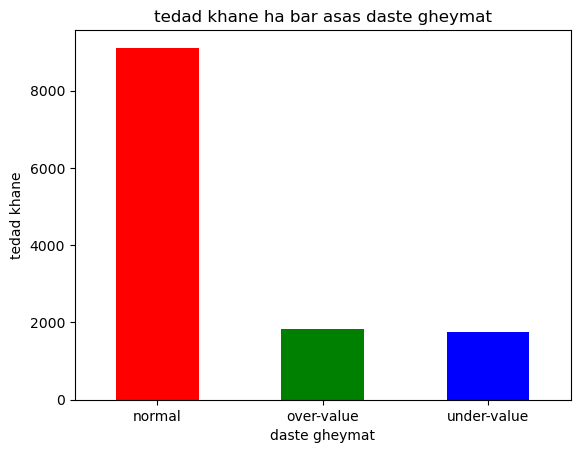

In [74]:
category_counts = test_df["price_category"].value_counts().sort_index()
category_counts.plot(kind="bar", color=["red", "green", "blue"])
plt.title("tedad khane ha bar asas daste gheymat")
plt.ylabel("tedad khane")
plt.xlabel("daste gheymat")
plt.xticks(rotation=0)
plt.show()


In [75]:
# میانگین متراژ و قیمت واقعی در هر دسته
print(test_df.groupby("price_category")[["building_size", "actual_price"]].mean())

# پنج محله با بیشترین آگهی در هر دسته
print(test_df.groupby("price_category")["neighborhood_slug"].value_counts().groupby(level=0).head(5))


                building_size  actual_price
price_category                             
normal              98.466081  8.990261e+09
over-value          94.021834  1.085288e+10
under-value         92.930699  4.245366e+09
price_category  neighborhood_slug
normal          poonak               290
                jeyhoun              246
                sazamn-barnameh      215
                sarsabil             212
                saadat-abad          176
over-value      poonak                89
                chitgar-lake          58
                sarsabil              51
                azarbaijan            49
                andisheh              41
under-value     shahr-e-ziba          69
                andisheh              64
                chitgar-lake          62
                chitgar               57
                tehransar             49
Name: count, dtype: int64


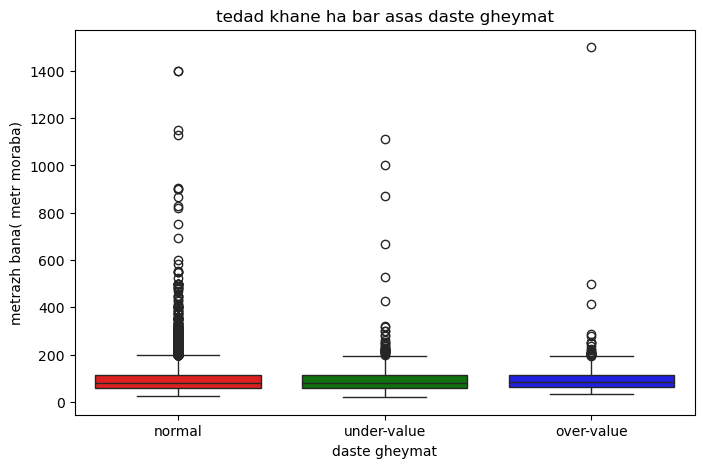

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=test_df, x="price_category", y="building_size", palette=["red", "green", "blue"])
plt.title("tedad khane ha bar asas daste gheymat")
plt.ylabel("metrazh bana( metr moraba)")
plt.xlabel("daste gheymat")
plt.show()


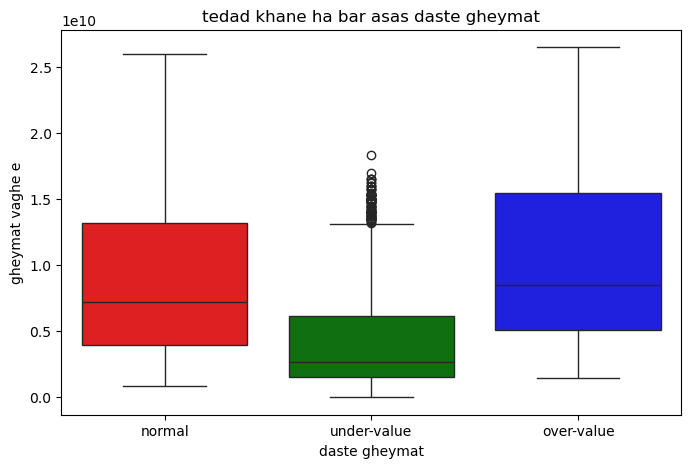

In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(data=test_df, x="price_category", y="actual_price", palette=["red", "green", "blue"])
plt.title("tedad khane ha bar asas daste gheymat")
plt.ylabel("gheymat vaghe e")
plt.xlabel("daste gheymat")
plt.show()


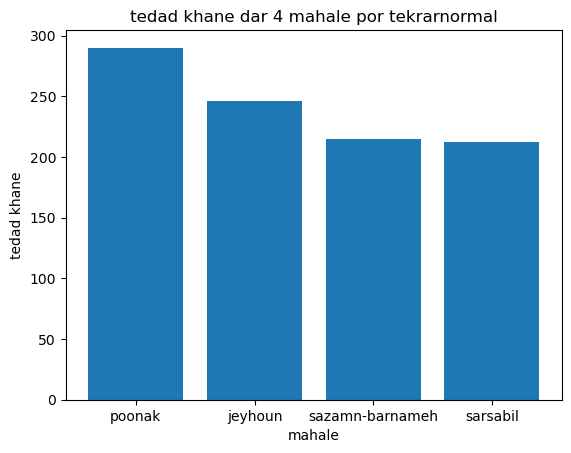

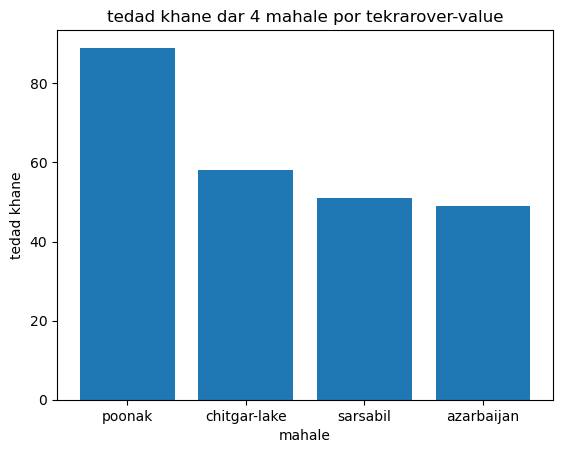

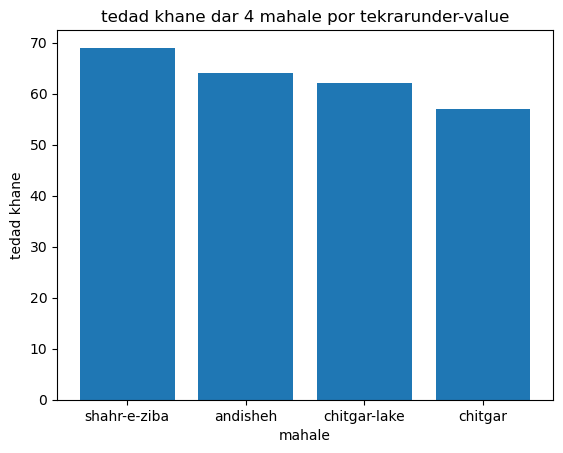

In [81]:
top_neigh = (
    test_df.groupby("price_category")["neighborhood_slug"]
    .value_counts()
    .rename("count")
    .reset_index()
)

for category in top_neigh['price_category'].unique():
    subset = top_neigh[top_neigh['price_category'] == category].nlargest(4, 'count')
    plt.bar(subset['neighborhood_slug'], subset['count'])
    plt.title(f"tedad khane dar 4 mahale por tekrar{category}")
    plt.ylabel("tedad khane")
    plt.xlabel("mahale")
    plt.show()
